# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [1]:
STUDENT_NAME = "Vo Le Thanh Trieu"  # TODO: Họ và tên
STUDENT_ID = "2453297"    # TODO: MSSV

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Vo Le Thanh Trieu (2453297)


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: /home/trieu_kernel/Desktop/win_desktop/HK253/ML_IOT_LAB/mliot-pyml-2026-hw/week02/numpy-pandas-eda-hw/data/automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [3]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [4]:
# TODO N1
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [5]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [6]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [7]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)

X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [8]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [9]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [10]:
# TODO N3
print(class_probabilities)
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = np.logical_or(~correct_mask, ~high_confidence_mask)
review_indices = np.where(review_mask)

[[0.65900114 0.24243297 0.09856589]
 [0.24472847 0.66524096 0.09003057]
 [0.00657326 0.01786798 0.97555875]
 [0.33333333 0.33333333 0.33333333]]


## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [11]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [12]:
# TODO N4
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0

augmented_batch = normalized_batch.copy()
augmented_batch = augmented_batch[:, :, ::-1, :]

augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

<!-- Viết câu trả lời tại đây. -->

1. Mỗi dòng đại diện cho đối tượng gì?
Mỗi dòng trong automobile_raw.csv đại diện cho một mẫu xe trong bộ dữ liệu 1985 Auto Imports.

2. Ký hiệu missing value trong CSV là gì?
Giá trị thiếu trong file được giữ dưới dạng ký hiệu ?.

3. symboling có ý nghĩa gì?
symboling là mức đánh giá rủi ro bảo hiểm của xe, nhận giá trị nguyên từ -3 đến 3, và cột này không có giá trị thiếu.



## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [13]:
# TODO D1
raw_df = pd.read_csv("data/automobile_raw.csv")
raw_shape = raw_df.shape
raw_missing_marker_count = (raw_df == '?').sum().sum()


print(raw_shape)
print(raw_missing_marker_count)
raw_df.head()

(205, 26)
59


,symboling,normalized_losses,make,fuel_type,aspiration,num_doors,body_style,drive_wheels,engine_location,wheel_base,...,engine_size,fuel_system,bore,stroke,compression_ratio,horsepower,peak_rpm,city_mpg,highway_mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [14]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [15]:
# TODO D2
df_clean = raw_df.replace('?', np.nan)
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column], errors='coerce')
missing_by_column = df_clean.isna().sum()


print(type(df_clean))
print(df_clean.dtypes)
print(missing_by_column)

<class 'pandas.core.frame.DataFrame'>
symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
en

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

<!-- Viết 3--6 câu tại đây. -->

## 1. Không fill mọi cột số bằng cùng một giá trị

- Mỗi cột số có ý nghĩa khác nhau (price, horsepower, …), nên không thể cùng dùng một số để “chữa cháy” cho tất cả.  
- Fill bừa sẽ làm méo trung bình, độ lệch chuẩn, tương quan… nên kết quả EDA không còn đáng tin.

## 2. Với `price`: nên drop hay fill?

- `price` là biến rất quan trọng, thường là mục tiêu phân tích.  
- Thiếu chỉ vài dòng, nên **drop những dòng thiếu `price`** để giữ kết quả phân tích sạch và đáng tin hơn.

## 3. `normalized_losses` thiếu nhiều thì ảnh hưởng gì?

- Thiếu 41 giá trị, tức là dữ liệu cho cột này ít hơn hẳn so với các cột khác.  
- Các thống kê, biểu đồ dùng `normalized_losses` sẽ dựa trên ít hàng, nên dễ nhiễu và kém tin cậy hơn.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [16]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [17]:
# TODO D3
analysis_df = df_clean[AUTO_FEATURES].dropna()
print(analysis_df)
X_auto = analysis_df.values.astype(np.float64)
print(X_auto)
print(type(X_auto))

auto_feature_mean = X_auto.mean(axis=0)
auto_feature_std = X_auto.std(axis=0)

X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
0           2548          130       111.0        21           27  13495.0
1           2548          130       111.0        21           27  16500.0
2           2823          152       154.0        19           26  16500.0
3           2337          109       102.0        24           30  13950.0
4           2824          136       115.0        18           22  17450.0
..           ...          ...         ...       ...          ...      ...
200         2952          141       114.0        23           28  16845.0
201         3049          141       160.0        19           25  19045.0
202         3012          173       134.0        18           23  21485.0
203         3217          145       106.0        26           27  22470.0
204         3062          141       114.0        19           25  22625.0

[199 rows x 6 columns]
[[2.5480e+03 1.3000e+02 1.1100e+02 2.1000e+01 2.7000e+01 1.3495e+04]
 [2.5480e+03 1.3000

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [18]:
# TODO D4
price_index = df_clean['price'].dropna().index
#print(price_index)
price_values = df_clean.loc[price_index, 'price'].values.astype(np.float64)
# print(price_values)
price_mean = price_values.mean()
price_std = price_values.std()

price_z = (price_values - price_mean) / price_std

price_outlier_mask = np.abs(price_z) > 2


price_outliers = df_clean.loc[price_index[price_outlier_mask]]
#print(price_outliers)



print("price_mean:", price_mean)
print("price_std:", price_std)
print("So luong outlier:", price_outlier_mask.sum())
print(price_outliers[['make', 'price']])

price_mean: 13207.129353233831
price_std: 7927.272870751161
So luong outlier: 14
              make    price
15             bmw  30760.0
16             bmw  41315.0
17             bmw  36880.0
47          jaguar  32250.0
48          jaguar  35550.0
49          jaguar  36000.0
70   mercedes-benz  31600.0
71   mercedes-benz  34184.0
72   mercedes-benz  35056.0
73   mercedes-benz  40960.0
74   mercedes-benz  45400.0
126        porsche  32528.0
127        porsche  34028.0
128        porsche  37028.0


## `.loc[price_index, 'price']` làm gì?

Cú pháp `.loc[A, B]` nghĩa là: "Cho tôi xem bảng, nhưng chỉ lấy dòng A và cột B."

- `A` = `price_index` = `[0, 2]` → chỉ lấy dòng 0 và dòng 2.
- `B` = `'price'` → chỉ lấy cột `price`.

Nói cách khác, câu lệnh là:

> "Trong bảng `df_clean`, hãy đưa tôi cột `price`, nhưng chỉ ở dòng 0 và dòng 2."

Kết quả:

​```text
0    15000
2     8000
​```

Không có dòng 1 (bmw) vì nó không nằm trong `price_index`.

## `price_outliers = df_clean.loc[price_index[price_outlier_mask]]`

Dòng này chọn ra những dòng bị coi là outlier trong `df_clean`, dựa trên kết quả z-score đã tính trước đó.

### Bước 1: `price_index[price_outlier_mask]`

- `price_index` là danh sách các dòng có `price` hợp lệ, ví dụ `[0, 2, 5, 7, ...]`.
- `price_outlier_mask` là mảng `True`/`False` cùng độ dài với `price_index`, đánh dấu dòng nào có `|z| > 2`.
- Khi đặt `price_outlier_mask` vào trong `[]` của `price_index`, pandas/NumPy sẽ lọc, chỉ giữ lại những phần tử của `price_index` tương ứng với `True`.

Ví dụ:

​```python
price_index = pd.Index()[1][2][3]
price_outlier_mask = np.array([False, True, False, True])

price_index[price_outlier_mask]
​```

Kết quả:

​```text
Index(, dtype='int64')[3][1]
​```

Nghĩa là: trong 4 dòng đang xét, chỉ dòng có index 2 và 7 là outlier.

### Bước 2: `df_clean.loc[...]`

- `.loc[price_index[price_outlier_mask]]` nghĩa là: "Lấy trong `df_clean` đúng những dòng có index nằm trong danh sách outlier vừa tìm được."
- Vì chỉ truyền một tham số (không có dấu phẩy phân cột), nên nó lấy toàn bộ các cột của những dòng đó, không chỉ riêng cột `price`.

Tiếp ví dụ:

​```python
price_outliers = df_clean.loc[price_index[price_outlier_mask]]
​```

Kết quả (giả sử `df_clean` có cột `make`, `price`, ...):

​```text
      make    price   ...
2     bmw     20970   ...
7     jaguar  32250   ...
​```

### Tóm gọn

- `price_index[price_outlier_mask]`: tìm ra index (số thứ tự dòng) của các xe bị coi là outlier về giá.
- `df_clean.loc[...]`: dùng index đó để lấy lại toàn bộ thông tin của những dòng đó (hãng xe, giá, các thông số khác), không chỉ riêng giá.

Kết quả cuối `price_outliers` là một DataFrame nhỏ, chứa đầy đủ thông tin các xe có giá bất thường (quá cao hoặc quá thấp so với phần còn lại).

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [19]:
# TODO D5
corr_df = df_clean[['engine_size', 'price']].dropna()
engine_price_corr = np.corrcoef(
    corr_df['engine_size'].values.astype(np.float64),
    corr_df['price'].values.astype(np.float64)
)[0, 1]

price_by_body_style = df_clean.groupby('body_style')['price'].mean().sort_index()

print("engine_price_corr:", engine_price_corr)
print(price_by_body_style)

#df_clean.groupby('body_style')['price'].head()

engine_price_corr: 0.8723351674455198
body_style
convertible    21890.500000
hardtop        22208.500000
hatchback       9957.441176
sedan          14459.755319
wagon          12371.960000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

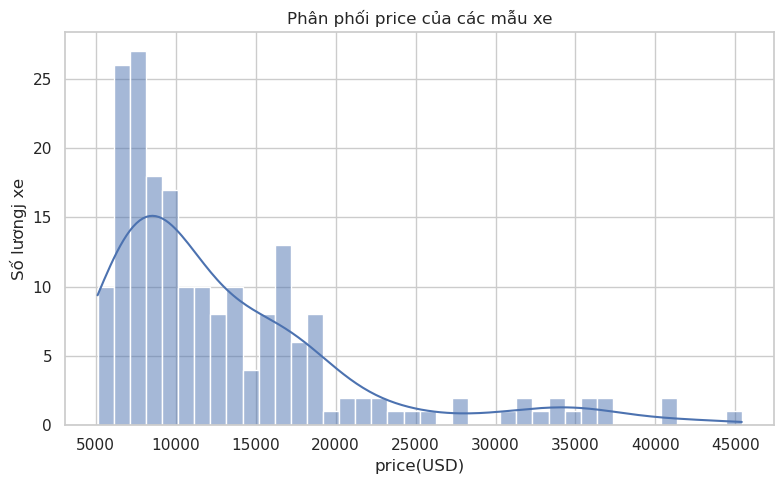

In [20]:
# TODO M2.1: histogram/KDE của price
fig, ax = plt.subplots(figsize= (8, 5))
sns.histplot(df_clean['price'].dropna(), bins = 40, kde = True, ax =ax)

ax.set_title("Phân phối price của các mẫu xe")
ax.set_xlabel("price(USD)")
ax.set_ylabel("Số lươngj xe")

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** Phần lớn xe có giá tập trung ở mức thấp–trung bình, và phân phối lệch phải (right-skewed) — tức có một số xe giá rất cao kéo dài đuôi phân phối sang bên phải.

## M2.2 Dataset có cân bằng theo body style không?

In [21]:
# print(df_clean['body_style'].value_counts().index)

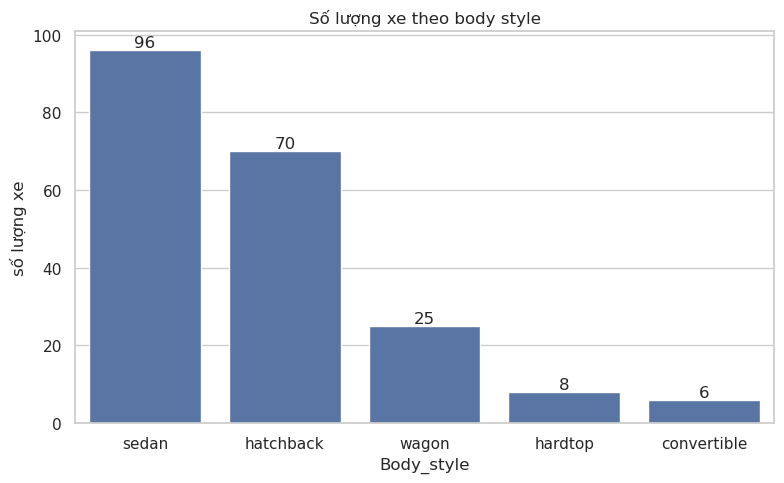

In [22]:
# TODO M2.2: countplot của body_style
fig, ax = plt.subplots(figsize = (8, 5))
sns.countplot(x = 'body_style', data = df_clean, order=df_clean['body_style'].value_counts().index, ax = ax)

ax.set_title("Số lượng xe theo body style")
ax.set_xlabel("Body_style")
ax.set_ylabel("số lượng xe")

for container in ax.containers:
    ax.bar_label(container)

# percentage label:
# for container in ax.containers:
#     labels = [f"{(v.get_height() / len(df_clean) * 100):.1f}%" for v in container]
#     ax.bar_label(container, labels=labels)

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** Dataset không cân bằng theo body_style — nhóm `sedan` và `hatchback` chiếm số lượng lớn nhất, trong khi các nhóm như `convertible` hoặc `hardtop` chỉ có rất ít xe.

## M2.3 Price khác nhau theo body style ra sao?

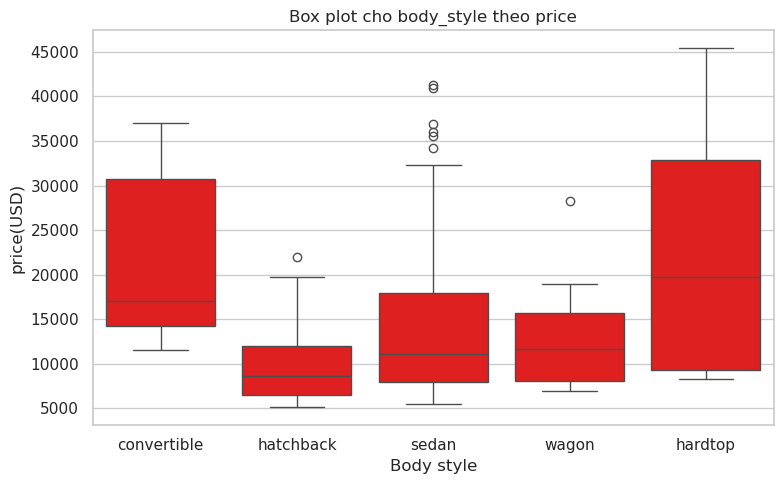

In [23]:
# TODO M2.3: boxplot price theo body_style
fig, ax = plt.subplots(figsize = (8, 5))
sns.boxplot(x = 'body_style', y = 'price', data = df_clean, ax = ax, color='red')

ax.set_title("Box plot cho body_style theo price")
ax.set_ylabel("price(USD)")
ax.set_xlabel("Body style")

plt.tight_layout()
plt.show()

## Trung vị (median) và ý nghĩa "ảnh hưởng"

Trung vị là **giá trị nằm chính giữa** khi sắp xếp toàn bộ số liệu từ nhỏ đến lớn, ít bị kéo lệch bởi các giá trị quá cao/quá thấp (outlier) như trung bình (mean).

### Nếu trung vị các nhóm giống nhau

​```text
sedan:       trung vị = 10000
hatchback:   trung vị = 10200
wagon:       trung vị =  9800
​```

Dù là sedan, hatchback, hay wagon, mức giá "chính giữa" đều xoay quanh 10000. Biết một xe thuộc `body_style` nào cũng không giúp đoán giá tốt hơn → `body_style` gần như **không ảnh hưởng** đến giá.

### Nếu trung vị các nhóm khác nhau rõ rệt

​```text
hardtop:     trung vị = 45400
hatchback:   trung vị =  6295
​```

Biết một xe là `hardtop` thì đoán giá cao (quanh 45400); biết là `hatchback` thì đoán giá thấp hơn nhiều (quanh 6295). Biết `body_style` giúp **đoán giá chính xác hơn** → `body_style` có liên quan/ảnh hưởng đến giá.

### Ví dụ đời thường

Giống như hỏi: "Sinh viên trường A và trường B lương ra trường có khác nhau không?"

- Lương trung vị 2 trường gần bằng nhau → trường học không phải yếu tố quyết định lương.
- Lương trung vị trường A cao hẳn trường B → trường học có vẻ liên quan đến mức lương.

Áp dụng vào boxplot `price` theo `body_style`: khoảng cách giữa các đường median trên chart cho biết `body_style` có tạo ra sự khác biệt về giá hay không — median gần nhau nghĩa là ít ảnh hưởng, median cách xa nhau nghĩa là ảnh hưởng rõ.

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** Nhóm `hardtop` và `convertible` có mức giá trung vị cao hơn rõ rệt so với `hatchback` và `sedan`, cho thấy body_style ảnh hưởng khá lớn đến giá xe.

## M2.4 Engine size liên quan thế nào tới price?

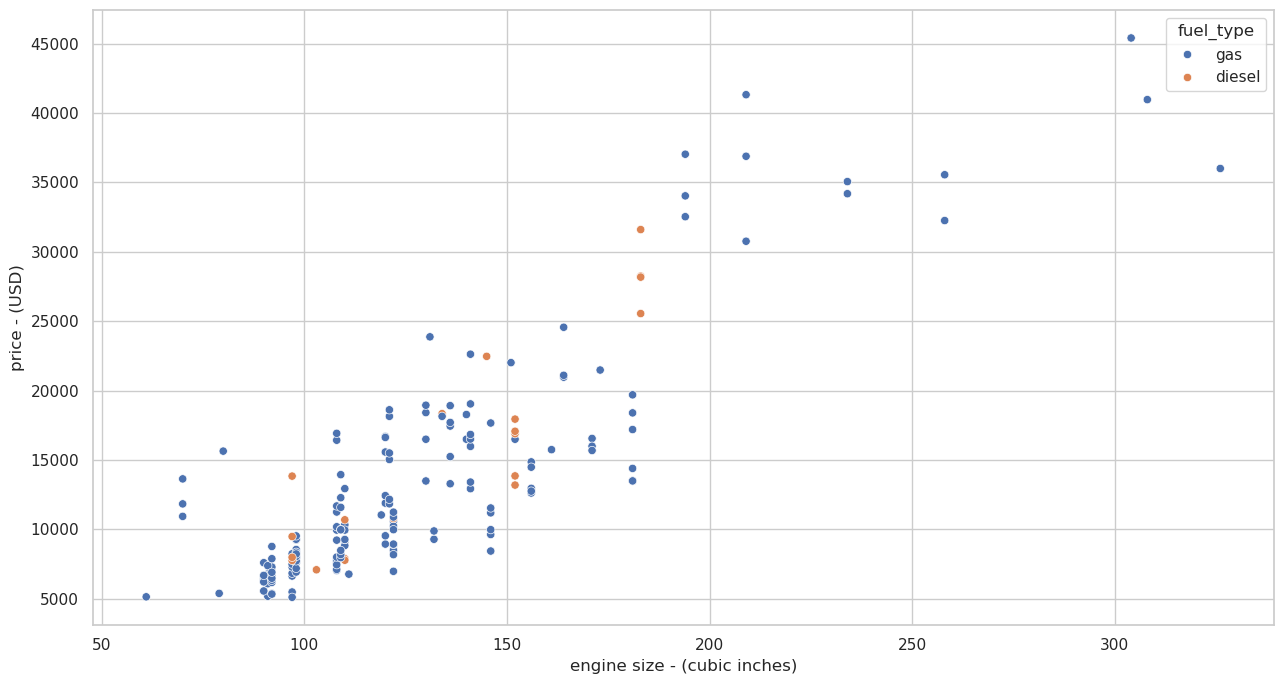

In [24]:
# TODO M2.4: scatterplot engine_size và price, hue=fuel_type
fig, ax = plt.subplots(figsize = (13, 7))
ax.set_xlabel("engine size - (cubic inches)")
ax.set_ylabel("price - (USD)")

sns.scatterplot(x = 'engine_size', y = 'price', data = df_clean, hue = 'fuel_type', ax = ax)

plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** Xe có `engine_size` lớn hơn thường có `price` cao hơn, cho thấy 2 biến này có tương quan dương khá rõ; xe chạy diesel (nếu có) thường nằm ở vùng engine lớn hơn nhóm gas.

## M2.5 Các feature numeric tương quan ra sao?

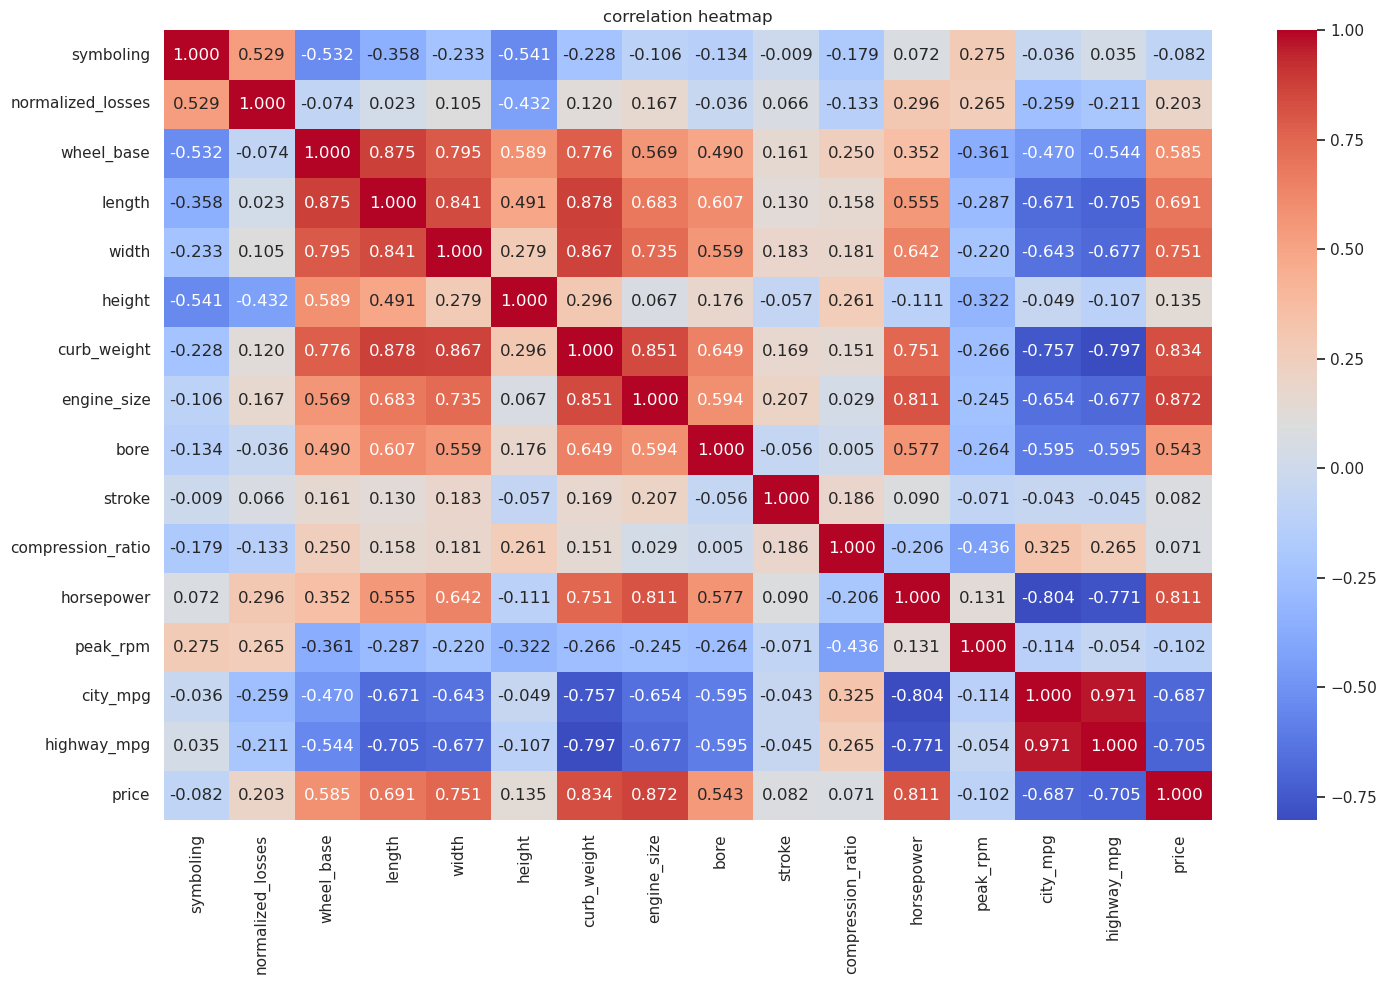

In [25]:
# TODO M2.5: correlation heatmap
fig, ax = plt.subplots(figsize = (15, 10 ))
ax.set_title("correlation heatmap")
numeric_cols = df_clean.select_dtypes(include = 'number').columns

correlation_mat = df_clean[numeric_cols].corr() # tính ma trận tương quan giữa các cặp biến

sns.heatmap(correlation_mat, annot = True,  fmt =".3f", cmap = "coolwarm", ax = ax)


plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** `engine_size` (0.87), `curb_weight` (0.83) và `horsepower` (0.81) có tương quan dương mạnh nhất với `price`, còn `city_mpg`/`highway_mpg` có tương quan âm rõ rệt (-0.69/-0.71) — xe càng lớn, càng khỏe thì càng đắt và càng ít tiết kiệm nhiên liệu.

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

Horsepower phân phối khác nhau thế nào theo drive_wheels (fwd/rwd/4wd)?

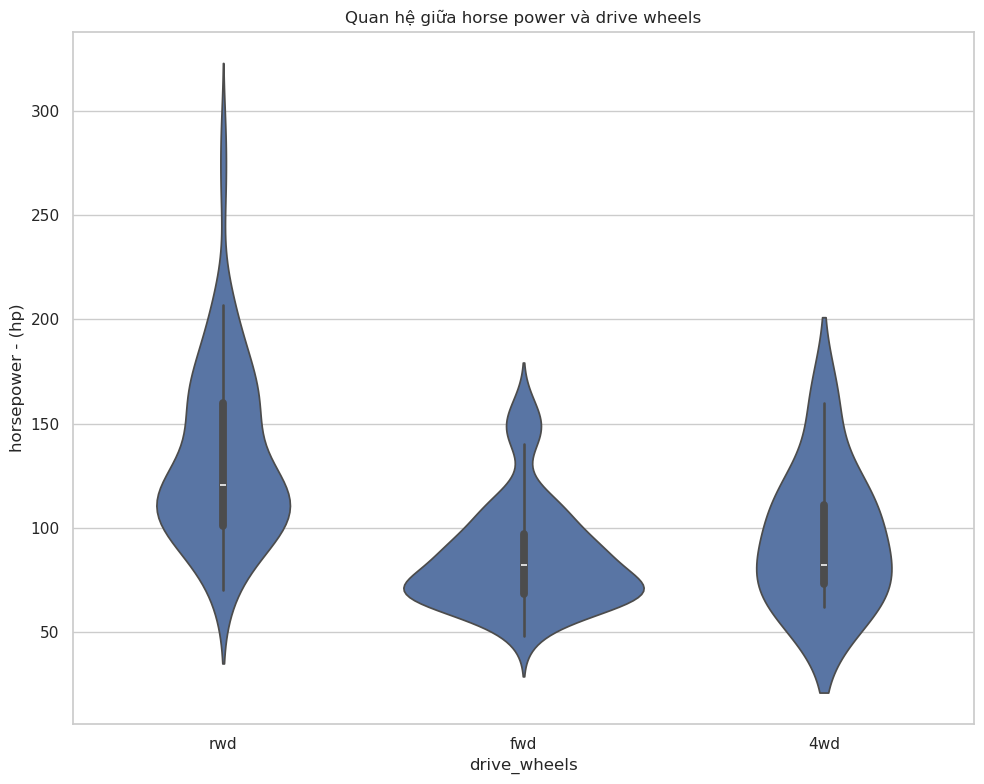

In [26]:
# TODO M2.6: biểu đồ tự chọn
fig, ax = plt.subplots(figsize = (10, 8))
ax.set_title("Quan hệ giữa horse power và drive wheels")
ax.set_xlabel("drive_wheels")
ax.set_ylabel("horsepower - (hp)")

sns.violinplot(x = 'drive_wheels', y = 'horsepower', data = df_clean, ax = ax)
plt.tight_layout()
plt.show()

**Nhận xét:** <!-- 1--2 câu -->

**Nhận xét:** Xe `rwd` có horsepower trung vị cao nhất (khoảng 120 hp) và trải rộng nhất (từ dưới 50 đến hơn 300 hp), trong khi `fwd` và `4wd` có trung vị thấp hơn (khoảng 80-85 hp) và phân phối hẹp hơn, cho thấy xe dẫn động cầu sau thường mạnh và đa dạng công suất hơn hẳn hai loại còn lại.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

<!-- Viết khoảng 150--250 từ. -->

## Tổng hợp

**3-5 phát hiện chính có dẫn chứng:**

- `price` phân phối lệch phải rõ rệt: đa số xe tập trung ở mức 5000-15000 USD, nhưng có một số xe giá rất cao (30000-45000 USD) kéo dài đuôi phân phối sang phải.
- Dataset không cân bằng theo `body_style`: `sedan` (96 xe) và `hatchback` (70 xe) chiếm đa số, trong khi `hardtop` (8 xe) và `convertible` (6 xe) rất ít mẫu.
- `body_style` có liên quan đến `price`: `hardtop` và `convertible` có median giá cao nhất (~17000-20000 USD), còn `hatchback` thấp nhất (~8500 USD).
- `engine_size` (0.87), `curb_weight` (0.83) và `horsepower` (0.81) có tương quan dương mạnh nhất với `price`; `city_mpg`/`highway_mpg` có tương quan âm mạnh (-0.69/-0.71) — xe càng lớn, càng khỏe thì càng đắt và càng tốn nhiên liệu.
- Xe `rwd` có horsepower trung vị cao nhất (~120 hp) và trải rộng nhất (35-320 hp), trong khi `fwd` có horsepower thấp và tập trung hơn (~48-180 hp).

**Ít nhất 2 hạn chế của dataset:**

- Một số nhóm `body_style` (`hardtop`: 8 xe, `convertible`: 6 xe) có mẫu quá nhỏ, khiến median/mean dễ bị lệch bởi 1-2 xe bất thường, không đại diện tốt cho cả nhóm.
- Dữ liệu có nhiều giá trị thiếu (`normalized_losses` thiếu nhiều nhất) và một số outlier giá rất cao (Mercedes, Jaguar, Porsche), có thể làm sai lệch các thống kê tổng thể nếu không xử lý kỹ.

**Một ví dụ về correlation không đồng nghĩa causation:**

`engine_size` tương quan cao với `price` (0.87), nhưng không có nghĩa là tăng dung tích động cơ sẽ trực tiếp làm xe đắt hơn — cả hai có thể cùng bị chi phối bởi yếu tố khác như hãng xe hoặc phân khúc thị trường (xe sang thường vừa có động cơ lớn vừa có giá cao).

**Một câu hỏi nên phân tích tiếp:**

Sau khi kiểm soát các biến kỹ thuật như `engine_size`, `horsepower`, `curb_weight`, liệu `body_style` và `make` còn thực sự ảnh hưởng đáng kể đến `price`, hay chỉ là biến trung gian phản ánh các đặc điểm kỹ thuật đó?